In [29]:
import pandas as pd

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

df = pd.read_csv('./data/pet_adoption_data.csv')

X = df.drop('AdoptionLikelihood', axis=1)
y = df['AdoptionLikelihood']
X.drop('PetID', axis=1, inplace=True)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [ ]:
kategoryczne = ['PetType', 'Breed', 'Color', 'Size']

ciągłe = ["AgeMonths", "WeightKg", "AdoptionFee", "DaysInShelter"]

bin = ['Vaccinated', "HealthCondition", "PreviosOwner"]


In [30]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, KBinsDiscretizer
from sklearn.naive_bayes import CategoricalNB


preprocessor = ColumnTransformer([
    ('num', KBinsDiscretizer(encode='ordinal'), ["AgeMonths", "WeightKg", "AdoptionFee", "TimeInShelterDays"]),
    ('cat', OneHotEncoder(handle_unknown='ignore'), ['PetType', 'Breed', 'Color', 'Size']),
    ('bin', 'passthrough', ['Vaccinated', "HealthCondition", "PreviousOwner"])
])

pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', CategoricalNB())
])

alpha = [x / 10 for  x in range(1, 11)]
#0.1, 0.2, ..., 1.0

n_bins = range(2, 11)
#2, 3, ..., 10

param_grid = {
    'prep__num__strategy': ['quantile', 'kmeans'],
    'prep__num__n_bins': n_bins,
    'model__alpha': alpha
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='precision')
grid_search.fit(X_train, y_train)

print(f"Najlepsze parametry: {grid_search.best_params_}")
print("Najlepszy wynik (Accuracy):", grid_search.best_score_)

model = grid_search.best_estimator_
y_pred = model.predict(X_test)

/home/maciek/ML_projekt/lista-4-projekt-grupowy-lematy/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/home/maciek/ML_projekt/lista-4-projekt-grupowy-lematy/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/home/maciek/ML_projekt/lista-4-projekt-grupowy-lematy/.venv/lib/python3.12/

Najlepsze parametry: {'model__alpha': 0.1, 'prep__num__n_bins': 8, 'prep__num__strategy': 'kmeans'}
Najlepszy wynik (Accuracy): 0.9004622005424574


/home/maciek/ML_projekt/lista-4-projekt-grupowy-lematy/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


Precision na zbiorze testowym: 0.8417


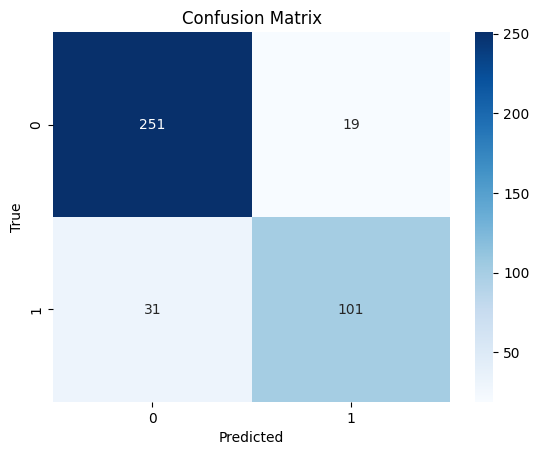

In [34]:
from sklearn.metrics import precision_score
from sklearn.metrics import confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

precision = precision_score(y_test, y_pred)
print(f"Precision na zbiorze testowym: {precision:.4f}")

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
results = pd.DataFrame(grid_search.cv_results_)
